#Rebekah Chandler
##Improving Cybersecurity Decision-Making Using Data Analytics
####Student ID: 81464636
####Program: Master of Science in Computer Science
####Institution: Angelo State University
####Semester: Spring 2026

##1. Environment Setup

In [1]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.dtypes import base
import os


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

#mount google drive
from google.colab import drive
drive.mount('/content/drive')

#define dataset base path
base_path = '/content/drive/MyDrive/capstone_project/data/cicids2017/machinelearningcve/'

Mounted at /content/drive


##2. Dataset Loading and Validation

###2.1 Tuesday Dataset

In [2]:
#load dataset
file_path = base_path + 'Tuesday-WorkingHours.pcap_ISCX.csv'
df = pd.read_csv(file_path)

#verify dataset structure
print('Shape:', df.shape)
print('Number of columns:', len(df.columns))
print('Last column:', df.columns[-1])

Shape: (445909, 79)
Number of columns: 79
Last column:  Label


###2.2 Friday Dataset

In [3]:
#load friday datasets
fri_morning = base_path + 'Friday-WorkingHours-Morning.pcap_ISCX.csv'
fri_ddos = base_path + 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
fri_portscan = base_path + 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'

df_fri_morning = pd.read_csv(fri_morning)
df_fri_ddos = pd.read_csv(fri_ddos)
df_fri_portscan = pd.read_csv(fri_portscan)

#combine friday dataset structure
df_fri = pd.concat(
    [df_fri_morning, df_fri_ddos, df_fri_portscan],
    ignore_index=True)

#verify dataset structure
print('Shape:', df_fri.shape)
print('Number of columns:', len(df_fri.columns))
print('Last column:', df_fri.columns[-1])


Shape: (703245, 79)
Number of columns: 79
Last column:  Label


##3. Exploratory Data Analysis (Tuesday)

###3.1  Standardize Column Names

In [4]:
#strip leading spaces
df.columns = df.columns.str.strip()



###3.2 Data Quality Assessment

In [5]:
#check for missing values
missing_total = df.isna().sum().sum()
print('Total missing values:', missing_total)

#check for infinite values
print('Total infinite values:', np.isinf(df.select_dtypes(include=[np.number])).values.sum())


Total missing values: 201
Total infinite values: 327


###3.3 Replace Infinite Values

In [6]:
#replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

#verify infinities are gone
print('Remaining infinite values:',
      np.isinf(df.select_dtypes(include=[np.number])).values.sum())


Remaining infinite values: 0


###3.4 Remove Missing Values

In [7]:
#remove rows with missing values
df.dropna(inplace=True)

print('Shape after removing missing values:', df.shape)

Shape after removing missing values: (445645, 79)


###3.5 Label Distribution and Class Imbalance

In [8]:
#analyze class distribution to identify imbalance
label_counts = df['Label'].value_counts()
label_pct = df['Label'].value_counts(normalize=True) * 100

#combine label counts and % distribution into one table
class_dis = pd.concat(
    [label_counts, label_pct.round(2)],
    axis=1)

class_dis.columns = ['Count', 'Percentage']
class_dis


,Count,Percentage
Label,,
BENIGN,431813,96.90
FTP-Patator,7935,1.78
SSH-Patator,5897,1.32


###3.6 Create Binary Target (Attack vs. Benign)

In [9]:
#define attack vs. benign
df["is_attack"] = (df["Label"] != "BENIGN").astype(int)

df['is_attack'].value_counts(normalize=True) *100

,proportion
is_attack,
0,96.896184
1,3.103816


###3.7 Baseline Using Majority Prediction

In [10]:
#define true labels(0=benign, 1=attack)
y_true = df['is_attack']

#majority-class baseline:  predict all traffic as benign(0)
y_pred = np.zeros_like(y_true)

#calculate standard evaluation metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

#compute confusion matrix to determine false positive rate
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

#false positive rate = benign incorrectly flagged as attack
fpr = fp / (fp + tn)

#store baseline results in table for reporting
baseline = pd.DataFrame({
    'Accuracy': round(acc, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1 Score': round(f1, 4),
    'False Positive Rate': round(fpr, 4)
}, index=[0])

baseline

,Accuracy,Precision,Recall,F1 Score,False Positive Rate
0,0.969,0.0,0.0,0.0,0.0


###3.8 Baseline Interpretation
The majority-class baseline achieves high overall accuracy (96.9%) due to class imbalance. However, it fails to detect any attack traffic, resulting in zero recall and zero F1 score. This demonstrates that accuracy alone is not an appropriate performance metric for intrusion detection and supports the need for more structured modeling in the next phase.

## 4.  Initial Machine Learning Models

In [11]:
# create modeling dataframe
model_df = df.copy()

# define features and target
X = model_df.drop(columns=['Label', 'is_attack'])
y = model_df['is_attack']

# keep only numeric features
X = X.select_dtypes(include=[np.number])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True))

Feature matrix shape: (445645, 78)
Target shape: (445645,)

Target distribution:
is_attack
0    0.968962
1    0.031038
Name: proportion, dtype: float64


### 4.1 Train/Test Split

In [12]:
#import train test split
from sklearn.model_selection import train_test_split

#split the data into training and tesitng sets
#80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#confirm the split worked as expected
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

#check that class distribution is consistent after split
print("\nTraining set distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting set distribution:")
print(y_test.value_counts(normalize=True))


Training set shape: (356516, 78)
Testing set shape: (89129, 78)

Training set distribution:
is_attack
0    0.968961
1    0.031039
Name: proportion, dtype: float64

Testing set distribution:
is_attack
0    0.968966
1    0.031034
Name: proportion, dtype: float64


### 4.2 Logistic Regression

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train model (handle class imbalance)
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

logreg.fit(X_train_scaled, y_train)

# predictions
y_pred_lr = logreg.predict(X_test_scaled)

# evaluation
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, zero_division=0)
lr_fpr = fp_lr / (fp_lr + tn_lr)

print("Logistic Regression Results")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(f"False Positive Rate: {lr_fpr:.4f}")

print("\nConfusion Matrix:")
print(cm_lr)

Logistic Regression Results
Accuracy: 0.9805
Precision: 0.6146
Recall: 0.9986
F1 Score: 0.7609
False Positive Rate: 0.0201

Confusion Matrix:
[[84631  1732]
 [    4  2762]]


#####4.2.1 Logistic Regression Confusion Matrix (Heatmap)

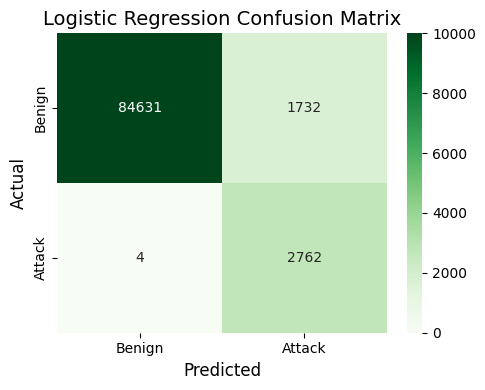

In [14]:
#create logistic regression confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'],
            vmin=0, vmax=10000,
            annot_kws={"size": 10})

#make title stand out and larger
plt.title('Logistic Regression Confusion Matrix', fontsize=14)

#make axis labels stand out
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

#make tick labels slightly smaller
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

###4.3 Decision Tree

In [15]:
#create decision tree
from sklearn.tree import DecisionTreeClassifier

#set up decision tree model use class_weight to handle imbalance
tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

#train the model
tree_model.fit(X_train, y_train)

#make predictions
y_pred_dt = tree_model.predict(X_test)

#evaluate performance
cm_dt = confusion_matrix(y_test, y_pred_dt)
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, zero_division=0)

#false positives = benign labeled as attack
dt_fpr = fp_dt / (fp_dt + tn_dt)

print("Decision Tree Results")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1 Score: {dt_f1:.4f}")
print(f"False Positive Rate: {dt_fpr:.4f}")

print("\nConfusion Matrix:")
print(cm_dt)


Decision Tree Results
Accuracy: 0.9999
Precision: 0.9996
Recall: 0.9982
F1 Score: 0.9989
False Positive Rate: 0.0000

Confusion Matrix:
[[86362     1]
 [    5  2761]]


####4.3.1 Decision Tree Confusion Matrix (Heatmap)

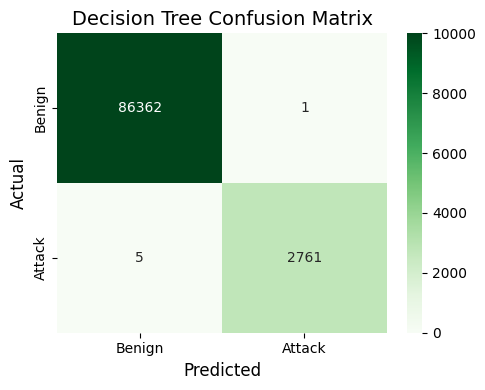

In [16]:
#create decision tree confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'],
            vmin=0, vmax=10000,
            annot_kws={'size': 10})

plt.title('Decision Tree Confusion Matrix', fontsize=14)
#make axis labels stand out
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

#make tick labels slightly smaller
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

###4.4 Model Comparison
The baseline model, logistic regression, and decision tree are compared using the same evaluation metrics. This makes it easier to see which model provides the best balance between detecting attacks and limiting false alarms.

In [17]:
#results table to compare all models in one place
#each directory is one model and its evaluation metrics

results = pd.DataFrame([

#baseline model
{
        'Model': 'Baseline',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'False Positive Rate': fpr
},

#logistic regression model results
{
    'Model': 'Logistic Regression',
    'Accuracy': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1 Score': lr_f1,
    'False Positive Rate': lr_fpr
},

#decision tree model results
{
    'Model': 'Decision Tree',
    'Accuracy': dt_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1 Score': dt_f1,
    'False Positive Rate': dt_fpr
}
 ])

#set the model names as the row lables
results_df = results.set_index('Model')

#display the results
results_df.round(4)

,Accuracy,Precision,Recall,F1 Score,False Positive Rate
Model,,,,,
Baseline,0.9690,0.0000,0.0000,0.0000,0.0000
Logistic Regression,0.9805,0.6146,0.9986,0.7609,0.0201
Decision Tree,0.9999,0.9996,0.9982,0.9989,0.0000


###4.5 Visual Comparison  
The chart below compares recall across the machine learning models for the Tuesday dataset. Recall is the focus here because the goal of this project is to catch as many attack events as possible.

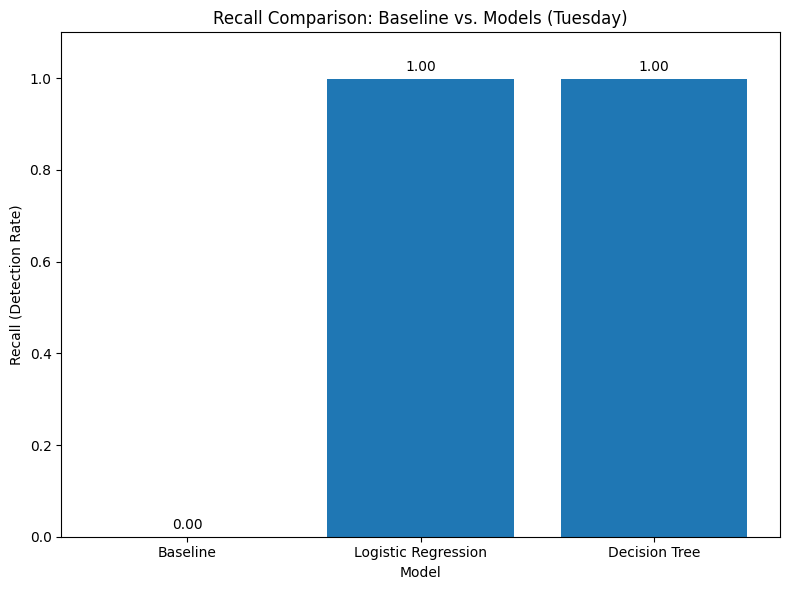

In [18]:
#create plot to compare models
plt.figure(figsize=(8, 6))

bars = plt.bar(results_df.index, results_df['Recall'], color='tab:blue')
plt.title('Recall Comparison: Baseline vs. Models (Tuesday)')

plt.xlabel('Model')
plt.ylabel('Recall (Detection Rate)')
plt.ylim(0, 1.10)

#add values to each bar in the middle of the bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom')

plt.tight_layout()
plt.show()

###4.6 Interpretation (Tuesday)

The baseline model had high accuracy but did not detect any attacks. Both logistic regression and the decision tree improved recall and were able to identify attack traffic.

Logistic regression detected slightly more attacks but also produced more false positives. The decision tree had similar recall but much fewer false positives.

Overall, the decision tree provides the best balance and is the most practical model for this problem.

##5. Exploratory Data Analysis (Friday)

###5.1 Standardize Column Names

In [19]:
#strip spaces in column names
df_fri.columns = df_fri.columns.str.strip()



###5.2 Data Quality Assessment

In [20]:
#check for missing values (Friday)
missing_total_fri = df_fri.isna().sum().sum()
print('Total missing values (Friday):', missing_total_fri)

#check for infinite values (Friday)
print(
    'Total infinite values (Friday):',
    np.isinf(df_fri.select_dtypes(include=[np.number])).values.sum()
)

Total missing values (Friday): 47
Total infinite values (Friday): 1007


###5.3 Replace Infinite Values

In [21]:
#replace ininite values in (friday) with NaN
df_fri.replace([np.inf, -np.inf], np.nan, inplace=True)

#verify infinite values are gone
print(
    'Remaining infinite values (Friday):',
    np.isinf(df_fri.select_dtypes(include=[np.number])).values.sum()
)

Remaining infinite values (Friday): 0


###5.4 Remove Missing Values

In [22]:
#remove rows (friday) with missing values
df_fri.dropna(inplace=True)

print('Shape after removing missing values (Friday):', df_fri.shape)

Shape after removing missing values (Friday): (702718, 79)


###5.5 Label Distribution and Class Imbalance

In [23]:
#analyze distribution (friday) to discover any class imbalance
label_counts_fri = df_fri['Label'].value_counts()
label_pct_fri = df_fri['Label'].value_counts(normalize=True) * 100

#combine label counts and % distribution into one table
class_dis_fri = pd.concat(
    [label_counts_fri, label_pct_fri.round(2)],
    axis=1)

class_dis_fri.columns = ['Count', 'Percentage']
class_dis_fri

,Count,Percentage
Label,,
BENIGN,413933,58.90
PortScan,158804,22.60
DDoS,128025,18.22
Bot,1956,0.28


###5.6 Create Binary Target (Attack vs. Benign)

In [24]:
#define attack vs. benign (friday)
df_fri["is_attack"] = (df_fri["Label"] != "BENIGN").astype(int)

df_fri['is_attack'].value_counts(normalize=True) *100

,proportion
is_attack,
0,58.904568
1,41.095432


##6. Initial Machine Learning Models (Friday)

In [25]:
#create modeling dataframe (friday)
model_df_fri = df_fri.copy()

#define features and target (friday)
X_fri = model_df_fri.drop(columns=['Label', 'is_attack'])
y_fri = model_df_fri['is_attack']

# keep only numeric features (friday)
X_fri = X_fri.select_dtypes(include=[np.number])

print("Feature matrix shape:", X_fri.shape)
print("Target shape:", y_fri.shape)

print("\nTarget distribution:")
print(y_fri.value_counts(normalize=True))

Feature matrix shape: (702718, 78)
Target shape: (702718,)

Target distribution:
is_attack
0    0.589046
1    0.410954
Name: proportion, dtype: float64


###6.1 Train/Test Split

In [26]:
#split the (friday) data into training and tesitng sets
#80% training, 20% testing
X_train_fri, X_test_fri, y_train_fri, y_test_fri = train_test_split(
    X_fri, y_fri,
    test_size=0.2,
    random_state=42,
    stratify=y_fri
)

#confirm the split worked as expected
print("Training set shape:", X_train_fri.shape)
print("Testing set shape:", X_test_fri.shape)

#check that class distribution is consistent after split
print("\nTraining set distribution (Friday):")
print(y_train_fri.value_counts(normalize=True))

print("\nTesting set distribution (Friday):")
print(y_test_fri.value_counts(normalize=True))



Training set shape: (562174, 78)
Testing set shape: (140544, 78)

Training set distribution (Friday):
is_attack
0    0.589045
1    0.410955
Name: proportion, dtype: float64

Testing set distribution (Friday):
is_attack
0    0.589047
1    0.410953
Name: proportion, dtype: float64


###6.2 Logistic Regression

In [ ]:
# scale features (friday)
scaler_fri = StandardScaler()
X_train_fri_scaled = scaler_fri.fit_transform(X_train_fri)
X_test_fri_scaled = scaler_fri.transform(X_test_fri)

# train model (handle class imbalance)
logreg_fri = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

logreg_fri.fit(X_train_fri_scaled, y_train_fri)

# predictions
y_pred_fri_lr = logreg_fri.predict(X_test_fri_scaled)

# evaluation
cm_lr_fri = confusion_matrix(y_test_fri, y_pred_fri_lr)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr_fri.ravel()

lr_accuracy_fri = accuracy_score(y_test_fri, y_pred_fri_lr)
lr_precision_fri = precision_score(y_test_fri, y_pred_fri_lr, zero_division=0)
lr_recall_fri = recall_score(y_test_fri, y_pred_fri_lr, zero_division=0)
lr_f1_fri = f1_score(y_test_fri, y_pred_fri_lr, zero_division=0)
lr_fpr_fri = fp_lr / (fp_lr + tn_lr)

print("Logistic Regression Results (Friday)")
print(f"Accuracy (Friday): {lr_accuracy_fri:.4f}")
print(f"Precision (Friday): {lr_precision_fri:.4f}")
print(f"Recall (Friday): {lr_recall_fri:.4f}")
print(f"F1 Score (Friday): {lr_f1_fri:.4f}")
print(f"False Positive Rate (Friday): {lr_fpr_fri:.4f}")

print("\nConfusion Matrix (Friday):")
print(cm_lr_fri)

####6.2.1 Logistic Regression Confusion Matrix (Heatmap)

In [ ]:
#create logistic regression confusion matrix heatmap (Friday)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr_fri, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'],
            annot_kws={"size": 10})

plt.title('Logistic Regression Confusion Matrix (Friday)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

###6.3 Decision Tree

In [ ]:
#create decision tree (friday)
from sklearn.tree import DecisionTreeClassifier

#set up decision tree model use class_weight to handle imbalance (friday)
tree_model_fri = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42)

#train the model (friday)
tree_model_fri.fit(X_train_fri, y_train_fri)

#make predictions (friday)
y_pred_fri_dt = tree_model_fri.predict(X_test_fri)

#evaluate performance (friday)
cm_dt_fri = confusion_matrix(y_test_fri, y_pred_fri_dt)
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt_fri.ravel()

dt_accuracy_fri = accuracy_score(y_test_fri, y_pred_fri_dt)
dt_precision_fri = precision_score(y_test_fri, y_pred_fri_dt, zero_division=0)
dt_recall_fri = recall_score(y_test_fri, y_pred_fri_dt, zero_division=0)
dt_f1_fri = f1_score(y_test_fri, y_pred_fri_dt, zero_division=0)

#false positives = benign labeled as attack
dt_fpr_fri = fp_dt / (fp_dt + tn_dt)

print("Decision Tree Results Friday")
print(f"Accuracy: {dt_accuracy_fri:.4f}")
print(f"Precision: {dt_precision_fri:.4f}")
print(f"Recall: {dt_recall_fri:.4f}")
print(f"F1 Score: {dt_f1_fri:.4f}")
print(f"False Positive Rate: {dt_fpr_fri:.4f}")

print("\nConfusion Matrix Friday:")
print(cm_dt_fri)


####6.3.1 Decision Tree Confusion Matrix (Heatmap)

In [ ]:
#create decision tree confusion matrix heatmap (friday)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt_fri, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'],
            annot_kws={'size': 10})

plt.title('Decision Tree Confusion Matrix (Friday)', fontsize=14)
#make axis labels stand out
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

#make tick labels slightly smaller
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

###6.4 Model Comparison

In [ ]:
#results table to compare all models in one place (friday)
#each directory is one model and its evaluation metrics

results_fri = pd.DataFrame([

#logistic regression model results (friday)

{
    'Model': 'Logistic Regression',
    'Accuracy': lr_accuracy_fri,
    'Precision': lr_precision_fri,
    'Recall': lr_recall_fri,
    'F1 Score': lr_f1_fri,
    'False Positive Rate': lr_fpr_fri
},

#decision tree model results
{
    'Model': 'Decision Tree',
    'Accuracy': dt_accuracy_fri,
    'Precision': dt_precision_fri,
    'Recall': dt_recall_fri,
    'F1 Score': dt_f1_fri,
    'False Positive Rate': dt_fpr_fri
}
 ])

#set the model names as the row lables
results_fri = results_fri.set_index('Model')

#display the results
print("Model Comparison Results (Friday)")
results_fri.round(4)

###6.5 Visual Comparison  
The chart below compares recall across the machine learning models for the Friday dataset. Recall is the focus here because the goal of this project is to catch as many attack events as possible.

In [ ]:
#create plot to compare models
plt.figure(figsize=(8, 6))

bars = plt.bar(results_fri.index, results_fri['Recall'], color='tab:blue')
plt.title('Recall Comparison: Models (Friday)')

plt.xlabel('Model')
plt.ylabel('Recall (Detection Rate)')
plt.ylim(0, 1.10)

#add values to each bar in the middle of the bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom')

plt.tight_layout()
plt.show()

##6.6 Inerpretation (Friday)
Both logistic regression and the decision tree performed very well on the Friday dataset and were able to detect most attack traffic.

Logistic regression achieved high recall but produced more false positives. The decision tree maintained similarly high recall while keeping false positives lower.

Overall, the decision tree provides the best balance and remains the more practical model, even on a different dataset.

##7. Comparison: Tuesday vs. Friday

In [ ]:
#combine tuesday and friday model results into one table

tuesday_compare = results_df.copy()
tuesday_compare['Dataset'] = 'Tuesday'

friday_compare = results_fri.copy()
friday_compare['Dataset'] = 'Friday'

#combine the two tables
combined_results = pd.concat([tuesday_compare, friday_compare])

combined_results = combined_results.reset_index()
combined_results = combined_results.set_index(['Dataset', 'Model'])
combined_results = combined_results.sort_index()

#reorder rows to match logical flow (Tuesday first, then Friday)
#keeps results consistent with earlier sections and easier to compare
combined_results = combined_results.reindex([
    ('Tuesday', 'Baseline'),
    ('Tuesday', 'Logistic Regression'),
    ('Tuesday', 'Decision Tree'),
    ('Friday', 'Logistic Regression'),
    ('Friday', 'Decision Tree')
])

#display results
combined_results.round(4)

This comparison was completed to evaluate how consistently the models performed across both datasets. For the Tuesday and Friday datasets, the same models and preprocessing steps were used to ensure a fair comparison.

The Tuesday dataset was highly imbalanced, which caused the baseline model to fail in detecting any attacks. In contrast, the Friday dataset was more balanced, resulting in both models performing well overall.

When comparing model performance across the two days, the following patterns were observed:

*   Logistic Regression: high recall, but more false positives
*   Decision Tree: similar recall, fewer false positives

Overall, the results were consistent across both datasets. The Decision Tree model provided the best balance and is the more practical model for detecting attacks.

##8. Conclusion

This project explored how machine learning models can be used to improve the detection of attack traffic using the CICIDS2017 dataset. Data preprocessing, exploratory analysis, and model evaluation were performed on both the Tuesday and Friday datasets to better understand how the models behave under different conditions.

The results showed that while logistic regression achieved high recall, it also produced more false positives. The decision tree model provided a better balance between detecting attacks and minimizing false positives. This pattern was consistent across both datasets, even though the level of class imbalance differed.

Overall, the decision tree model was the most practical choice for this problem. These results demonstrate that interpretable models can be effective tools for supporting cybersecurity decision-making.